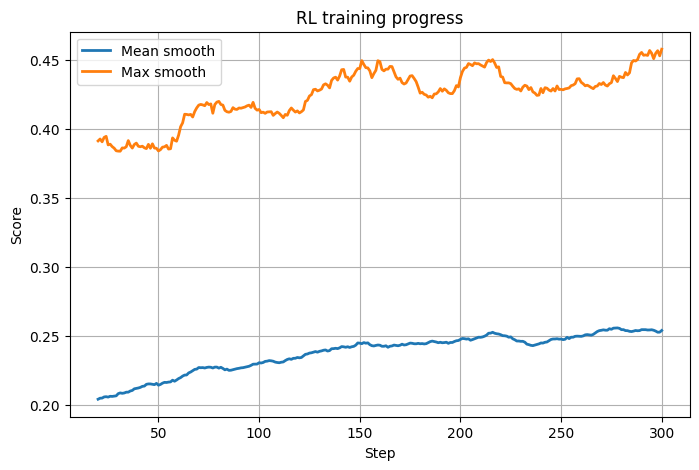

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("qsar_extproc_1.csv")

# агрегируем по шагам
agg = df.groupby("step").agg({
    "Score": ["mean", "max"],
})

agg.columns = ["score_mean", "score_max"]
agg = agg.reset_index()

# график
plt.figure(figsize=(8,5))

agg["mean_smooth"] = agg["score_mean"].rolling(20).mean()
agg["max_smooth"] = agg["score_max"].rolling(20).mean()

plt.plot(agg["step"], agg["mean_smooth"], label="Mean smooth", linewidth=2)
plt.plot(agg["step"], agg["max_smooth"], label="Max smooth", linewidth=2)

plt.xlabel("Step")
plt.ylabel("Score")
plt.title("RL training progress")
plt.legend()
plt.grid()

plt.show()